# 0-1. Google Drive 마운트

In [2]:
from google.colab import drive

In [6]:
drive.mount('/content/drive')

Mounted at /content/drive


# 0-2. 패키지 설치

In [9]:
# openbabel
!apt-get install -y openbabel libopenbabel-dev -q

# rdkit
!pip install rdkit -q

# cmake
!apt-get install -y cmake -q

# pdbfixer
!pip install pdbfixer -q

# biopython
!pip install biopython -q

Reading package lists...
Building dependency tree...
Reading state information...
The following additional packages will be installed:
  libboost-iostreams1.83.0 libinchi1 libmaeparser1 libopenbabel7
Suggested packages:
  libopenbabel-doc
The following NEW packages will be installed:
  libboost-iostreams1.83.0 libinchi1 libmaeparser1 libopenbabel-dev
  libopenbabel7 openbabel
0 upgraded, 6 newly installed, 0 to remove and 11 not upgraded.
Need to get 4,363 kB of archives.
After this operation, 19.7 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu noble-updates/main amd64 libboost-iostreams1.83.0 amd64 1.83.0-2.1ubuntu3.2 [260 kB]
Get:2 http://archive.ubuntu.com/ubuntu noble/universe amd64 libinchi1 amd64 1.03+dfsg-4build1 [463 kB]
Get:3 http://archive.ubuntu.com/ubuntu noble/universe amd64 libmaeparser1 amd64 1.3.1-1build1 [90.2 kB]
Get:4 http://archive.ubuntu.com/ubuntu noble/universe amd64 libopenbabel7 amd64 3.1.1+dfsg-9ubuntu5 [3,240 kB]
Get:5 http:/

In [11]:
!pip install openbabel-wheel -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.1/16.1 MB 37.7 MB/s eta 0:00:00


In [12]:
from rdkit import Chem
import openbabel
print("rdkit OK")
print("openbabel OK")

rdkit OK
openbabel OK


# 0-3. 작업 폴더로 이동

In [13]:
%cd "/content/drive/MyDrive/4. ML DL archive/0. 생명정보학 및 신약 개발 개념 노트/LAIDD 신약 개발 강의 노트/중급 강의 노트/단백질 구조 기반 약물탐색/2. PDB 분석/practice_2"


/content/drive/MyDrive/4. ML DL archive/0. 생명정보학 및 신약 개발 개념 노트/LAIDD 신약 개발 강의 노트/중급 강의 노트/단백질 구조 기반 약물탐색/2. PDB 분석/practice_2


# 0-4. PBI toolkit 압축 해제

In [14]:
!unzip PBI.zip -d .
!cp -rf PBI/script TGFR1
%cd TGFR1

Archive:  PBI.zip
   creating: ./PBI/
   creating: ./PBI/script/
  inflating: ./PBI/script/dock_vina.sh  
  inflating: ./PBI/script/pymol_code.sh  
  inflating: ./PBI/script/auto_box.sh  
  inflating: ./PBI/script/check_water.sh  
  inflating: ./PBI/script/split_ligand.sh  
  inflating: ./PBI/script/auto_run.sh  
  inflating: ./PBI/script/dist.sh    
  inflating: ./PBI/script/pymol.sh   
  inflating: ./PBI/script/dw_lig_ref.sh  
  inflating: ./PBI/script/split_chain.sh  
  inflating: ./PBI/script/readme.txt  
  inflating: ./PBI/script/fix.sh     
  inflating: ./PBI/script/cp_pdb.sh  
  inflating: ./PBI/script/gen_chain_list.py  
  inflating: ./PBI/script/rot.sh     
  inflating: ./PBI/script/dock_vina.py  
  inflating: ./PBI/LICENSE           
 extracting: ./PBI/README.md         
   creating: ./PBI/pbi/
  inflating: ./PBI/pbi/pdbtools.py   
  inflating: ./PBI/pbi/nwa.py        
  inflating: ./PBI/pbi/ligandtools.py  
 extracting: ./PBI/pbi/__init__.py   
  inflating: ./PBI/environment

# Step 1 - UniProt DB 구축

In [19]:
import os
os.chdir("/content/drive/MyDrive/4. ML DL archive/0. 생명정보학 및 신약 개발 개념 노트/LAIDD 신약 개발 강의 노트/중급 강의 노트/단백질 구조 기반 약물탐색/2. PDB 분석/practice_2")

# PBI 패키지 설치 (setup.py 기반)
!pip install -e PBI/ -q

# 설치 확인
!which uniprot_dict.py

  Preparing metadata (setup.py) ... done
/usr/local/bin/uniprot_dict.py


In [20]:
# UniProt DB 저장 폴더 생성
!mkdir -p "/content/drive/MyDrive/Database/uniprot"

# UniProt Swiss-Prot DB 다운로드 (~600MB)
!wget https://ftp.uniprot.org/pub/databases/uniprot/current_release/knowledgebase/complete/uniprot_sprot.dat.gz \
    -P "/content/drive/MyDrive/Database/uniprot/" --show-progress

--2026-09-10 08:10:53--  https://ftp.uniprot.org/pub/databases/uniprot/current_release/knowledgebase/complete/uniprot_sprot.dat.gz
Resolving ftp.uniprot.org (ftp.uniprot.org)... 128.175.240.195
Connecting to ftp.uniprot.org (ftp.uniprot.org)|128.175.240.195|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 700301138 (668M) [application/x-gzip]
Saving to: ‘/content/drive/MyDrive/Database/uniprot/uniprot_sprot.dat.gz.1’

uniprot_sprot.dat.g 100%[===================>] 667.86M  42.7MB/s    in 15s     

2026-09-10 08:11:09 (43.5 MB/s) - ‘/content/drive/MyDrive/Database/uniprot/uniprot_sprot.dat.gz.1’ saved [700301138/700301138]



In [21]:
# TGFR1 작업 폴더로 이동
import os
os.chdir("/content/drive/MyDrive/4. ML DL archive/0. 생명정보학 및 신약 개발 개념 노트/LAIDD 신약 개발 강의 노트/중급 강의 노트/단백질 구조 기반 약물탐색/2. PDB 분석/practice_2/TGFR1")

# DB 경로 설정
!echo "db_dir=/content/drive/MyDrive/Database/uniprot" > db_dir.txt

# DB 파싱 (최초 1회, 수분 소요)
!uniprot_dict.py make_pickle

# Step 2- 타겟 단백질 정보 추출

In [22]:
# 타겟 단백질 서열 및 PDB 목록 추출
!uniprot_dict.py pdb TGFR1_HUMAN

P36897 TGFR1 TGFBR1 7046


In [23]:
!cat P36897.fasta
!cat P36897_pdb_list.txt

>sp|P36897|TGFR1_HUMAN TGF-beta receptor type-1 OS=Homo sapiens OX=9606 GN=TGFBR1 PE=1 SV=1
MEAAVAAPRPRLLLLVLAAAAAAAAALLPGATALQCFCHLCTKDNFTCVTDGLCFVSVTE
TTDKVIHNSMCIAEIDLIPRDRPFVCAPSSKTGSVTTTYCCNQDHCNKIELPTTVKSSPG
LGPVELAAVIAGPVCFVCISLMLMVYICHNRTVIHHRVPNEEDPSLDRPFISEGTTLKDL
IYDMTTSGSGSGLPLLVQRTIARTIVLQESIGKGRFGEVWRGKWRGEEVAVKIFSSREER
SWFREAEIYQTVMLRHENILGFIAADNKDNGTWTQLWLVSDYHEHGSLFDYLNRYTVTVE
GMIKLALSTASGLAHLHMEIVGTQGKPAIAHRDLKSKNILVKKNGTCCIADLGLAVRHDS
ATDTIDIAPNHRVGTKRYMAPEVLDDSINMKHFESFKRADIYAMGLVFWEIARRCSIGGI
HEDYQLPYYDLVPSDPSVEEMRKVVCEQKLRPNIPNRWQSCEALRVMAKIMRECWYANGA
ARLTALRIKKTLSQLSQQEGIKM
1B6C;X-ray;2.60 A;B/D/F/H=162-503
1IAS;X-ray;2.90 A;A/B/C/D/E=162-503
1PY5;X-ray;2.30 A;A=175-500
1RW8;X-ray;2.40 A;A=200-500
1VJY;X-ray;2.00 A;A=201-503
2L5S;NMR;-;A=31-115
2PJY;X-ray;3.00 A;C=33-111
2WOT;X-ray;1.85 A;A=200-503
2WOU;X-ray;2.30 A;A=200-503
2X7O;X-ray;3.70 A;A/B/C/D/E=162-503
3FAA;X-ray;3.35 A;A/B/C/D/E=162-503
3GXL;X-ray;1.80 A;A=201-503
3HMM;X-ray;1.70 A;A=201-503
3KCF;X-ray;

# Step 3 - Kinase Domain 포함 PDB 필터링

**필터링 근거:**
- TGFR1의 kinase domain은 잔기 205-495에 위치
- 세포외 도메인 포함 구조는 도킹 목적과 무관하므로 제외

> **한계:** 해당 영역이 일부 누락된 경우도 통과할 수 있음.

In [24]:
# Kinase domain (205-495) 포함 PDB만 필터링
!filter_pdb_list.py P36897_pdb_list.txt -r 205-495 > P36897_pdb_list_filter.txt
!cat P36897_pdb_list_filter.txt

1B6C;X-ray;2.60 A;B/D/F/H=162-503
1IAS;X-ray;2.90 A;A/B/C/D/E=162-503
1PY5;X-ray;2.30 A;A=175-500
1RW8;X-ray;2.40 A;A=200-500
1VJY;X-ray;2.00 A;A=201-503
2WOT;X-ray;1.85 A;A=200-503
2WOU;X-ray;2.30 A;A=200-503
2X7O;X-ray;3.70 A;A/B/C/D/E=162-503
3FAA;X-ray;3.35 A;A/B/C/D/E=162-503
3GXL;X-ray;1.80 A;A=201-503
3HMM;X-ray;1.70 A;A=201-503
3KCF;X-ray;2.80 A;A/B/C/D/E=162-503
3TZM;X-ray;1.70 A;A=200-503
4X0M;X-ray;1.68 A;A=200-503
4X2F;X-ray;1.49 A;A=200-503
4X2G;X-ray;1.51 A;A=200-503
4X2J;X-ray;1.69 A;A=200-503
4X2K;X-ray;1.69 A;A=200-503
4X2N;X-ray;1.80 A;A=200-503
5E8S;X-ray;1.45 A;A=200-503
5E8T;X-ray;1.70 A;A=200-503
5E8U;X-ray;2.03 A;A=200-503
5E8W;X-ray;1.86 A;A=200-503
5E8X;X-ray;1.45 A;A=200-503
5E8Z;X-ray;1.51 A;A=200-503
5E90;X-ray;2.05 A;A=200-503
5FRI;X-ray;2.00 A;A=200-498
5QIK;X-ray;1.58 A;A=200-503
5QIL;X-ray;1.98 A;A=200-503
5QIM;X-ray;1.75 A;A=200-503
5QTZ;X-ray;1.83 A;A=200-503
5QU0;X-ray;1.67 A;A=200-503
5USQ;X-ray;2.55 A;A=200-498
6B8Y;X-ray;1.65 A;A=200-503
8YHF;X-ray

# Step 4 - PDB 파일 다운로드

In [25]:
# 필터링된 PDB 파일 일괄 다운로드
!dw_pdb.py P36897_pdb_list_filter.txt pdb
!ls pdb

1B6C
1IAS
1PY5
1RW8
1VJY
2WOT
2WOU
2X7O
3FAA
3GXL
3HMM
3KCF
3TZM
4X0M
4X2F
4X2G
4X2J
4X2K
4X2N
5E8S
5E8T
5E8U
5E8W
5E8X
5E8Z
5E90
5FRI
5QIK
5QIL
5QIM
5QTZ
5QU0
5USQ
6B8Y
8YHF
Traceback (most recent call last):
  File "/usr/local/bin/dw_pdb.py", line 59, in <module>
    main()
    ~~~~^^
  File "/usr/local/bin/dw_pdb.py", line 42, in main
    request.urlretrieve(line_pdb, pdb_gz_file)
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.13/urllib/request.py", line 214, in urlretrieve
    with contextlib.closing(urlopen(url, data)) as fp:
                            ~~~~~~~^^^^^^^^^^^
  File "/usr/lib/python3.13/urllib/request.py", line 189, in urlopen
    return opener.open(url, data, timeout)
           ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.13/urllib/request.py", line 495, in open
    response = meth(req, response)
  File "/usr/lib/python3.13/urllib/request.py", line 604, in http_response
    response = self.parent.error(
        'http', request, r

35개 다운로드 완료됐고, 마지막 3개(8YHF, 8YHL, 9J9D)가 404 오류로 실패..
최신 PDB ID라 URL 형식이 변경된 것입니다. 무시하고 Step 5로 진행.

# Step 5 - Mutation 확인 및 리간드 종류 확인

In [26]:
# Mutation 확인 및 리간드 종류 확인
!find_mutation_pdb.py P36897_pdb_list_filter.txt P36897.fasta pdb > list_mutation.txt
!cat list_mutation.txt

1B6C;B/D/F/H;SO4;wild_type
1IAS;A/B/C/D/E;SO4;wild_type
1PY5;A;PY1,SO4;wild_type
1RW8;A;580;wild_type
1VJY;A;460;wild_type
2WOT;A;EDO,ZZG;wild_type
2WOU;A;EDO,ZZF;wild_type
2X7O;A/B/C/D/E;ZOP;wild_type
3FAA;A/B/C/D/E;55F,PO4;wild_type
3GXL;A;QIG;wild_type
3HMM;A;855;wild_type
3KCF;A/B/C/D/E;JZO,PO4;wild_type
3TZM;A;085;wild_type
4X0M;A;3WA,SO4;wild_type
4X2F;A;3WJ,SO4;wild_type
4X2G;A;3WK,SO4,TRS;wild_type
4X2J;A;3WN,SO4;wild_type
4X2K;A;3WO,SO4;wild_type
4X2N;A;SO4;wild_type
5E8S;A;;wild_type
5E8T;A;GOL;R199-,T204D
5E8U;A;GOL;R199-,T204D,I211V,Y249F,S280T,Y282F,S287N,A350C,L352F
5E8W;A;GOL,STU;R199-,T204D
5E8X;A;GOL,STU;R199-,T204D,I211V,Y249F,S280T,Y282F,S287N,A350C,L352F
5E8Z;A;5L4;R199-,T204D
5E90;A;5L4;R199-,T204D,I211V,Y249F,S280T,Y282F,S287N,A350C,L352F
5FRI;A;EDO,ZUQ;wild_type
5QIK;A;GOL,J2M;R199-,T204D
5QIL;A;J2V;R199-,T204D
5QIM;A;GOL,J2Y;wild_type
5QTZ;A;GOL,QMY;R199-,T204D
5QU0;A;GOL,QMV;R199-,T204D
5USQ;A;8LY;wild_type
6B8Y;A;D0A;R199-,T204D
pdb/8YHF.pdb does not exist
pdb

## list_mutation.txt 결과 해석


*   Wild type 구조 (도킹에 적합):

리간드 있음: 1RW8, 1VJY, 2WOT, 2WOU, 3GXL, 3HMM, 3TZM, 4X0M, 4X2F, 4X2G, 4X2J, 4X2K, 5FRI, 5QIM, 5USQ
리간드 없음(SO4만): 1B6C, 1IAS, 4X2N, 5E8S

<br>

*   Mutation 구조 (별도 처리 필요):

5E8T, 5E8U, 5E8W, 5E8X, 5E8Z, 5E90, 5QIK, 5QIL, 5QTZ, 5QU0, 6B8Y — 모두 R199-, T204D 포함

<br>

*   다운로드 실패 (무시):

8YHF, 8YHL, 9F6X, 9J9D

# Step 6 — PyMOL 구조 정렬 (Windows)

In [ ]:
#Colab에서 다운로드한 `pdb/` 폴더를 Drive를 통해 로컬로 가져온 후 PyMOL에서 실행:
# PyMOL 내에서 실행
## cd C:/Users/PC/Downloads/pdb-20260910T082612Z-1-001/pdb
## fetch 3HMM 1RW8 1VJY 2WOT 2WOU 3GXL 3TZM 4X0M 4X2F 4X2G 4X2J 4X2K 5FRI 5QIM 5USQ, async=0
### Wild type + 리간드 있는 구조만 선택


### align 이전

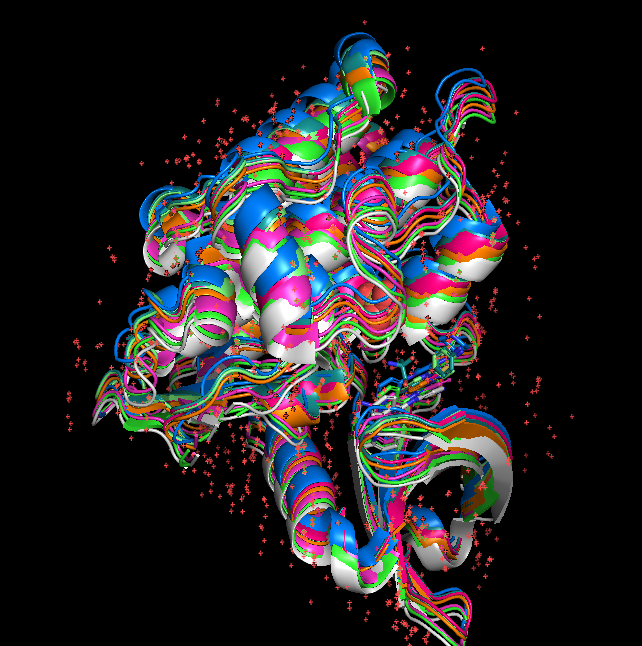

### align 이후

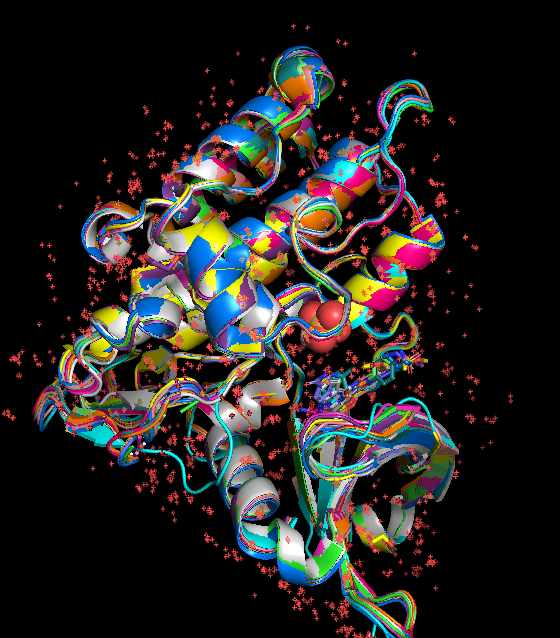

In [ ]:
#PyMOL>alignto 3HMM
#1RW8                 RMSD =    0.837 (288 atoms)
#1VJY                 RMSD =    0.686 (288 atoms)
#2WOT                 RMSD =    0.513 (288 atoms)
#2WOU                 RMSD =    0.510 (288 atoms)
#3GXL                 RMSD =    1.393 (280 atoms)
#3TZM                 RMSD =    0.316 (288 atoms)
#4X0M                 RMSD =    0.550 (288 atoms)
#4X2F                 RMSD =    0.546 (288 atoms)
#4X2G                 RMSD =    0.568 (288 atoms)
#4X2J                 RMSD =    0.560 (288 atoms)
#4X2K                 RMSD =    0.560 (288 atoms)
#5FRI                 RMSD =    0.337 (288 atoms)
#5QIM                 RMSD =    0.457 (288 atoms)
#5USQ                 RMSD =    0.602 (288 atoms)

구조	/ RMSD (Å)	/ 해석
<br>
3TZM	/ 0.316 /	3HMM과 가장 유사
<br>
5FRI	/ 0.337	/ 매우 유사
<br>
2WOT, 2WOU	/ 0.510~0.513	/ 유사
<br>
3GXL	/ 1.393	/ 가장 큰 편차 → 루프 구조 차이 가능성

# Step 7 - Chain 분리 및 TGFR1 Chain 선택

Chain 분리 이유

PDB 파일 하나에 여러 단백질이 함께 들어있을 수 있습니다:
<br>
<br>
상황	예시	문제
<br>
Homo	3HMM: Chain A만 TGFR1	단일 chain만 필요
<br>
Hetero	1B6C: Chain B/D/F/H — 여러 단백질 복합체	TGFR1 chain만 추출 필요

<br>
<br>
도킹 시 TGFR1 단독 구조가 필요하므로 chain별로 분리합니다.

In [31]:
!split_chain.py -h

usage: split_chain.py [-h] -i INPUT_FILE [-d OUT_DIR] [-e]

split chain from pdb

options:
  -h, --help            show this help message and exit
  -i, --input_file INPUT_FILE
                        input protein pdb file
  -d, --out_dir OUT_DIR
                        output directory
  -e, --exclude_water   if exist, exclude water atoms


In [32]:
import os

os.makedirs("chain", exist_ok=True)

# list_mutation.txt에서 PDB ID와 chain 목록 읽어서 하나씩 분리
with open("list_mutation.txt") as f:
    for line in f:
        line = line.strip()
        if not line or "does not exist" in line:
            continue
        parts = line.split(";")
        pdb_id = parts[0]
        pdb_file = f"pdb/{pdb_id}.pdb"
        if os.path.exists(pdb_file):
            !split_chain.py -i {pdb_file} -d chain -e
            print(f"{pdb_id} 완료")

1B6C 완료
1IAS 완료
1PY5 완료
1RW8 완료
1VJY 완료
2WOT 완료
2WOU 완료
2X7O 완료
3FAA 완료
3GXL 완료
3HMM 완료
3KCF 완료
3TZM 완료
4X0M 완료
4X2F 완료
4X2G 완료
4X2J 완료
4X2K 완료
4X2N 완료
5E8S 완료
5E8T 완료
5E8U 완료
5E8W 완료
5E8X 완료
5E8Z 완료
5E90 완료
5FRI 완료
5QIK 완료
5QIL 완료
5QIM 완료
5QTZ 완료
5QU0 완료
5USQ 완료
6B8Y 완료


In [33]:
!ls chain | head -20

1B6CA.pdb
1B6CB.pdb
1B6CC.pdb
1B6CD.pdb
1B6CE.pdb
1B6CF.pdb
1B6CG.pdb
1B6CH.pdb
1IASA.pdb
1IASB.pdb
1IASC.pdb
1IASD.pdb
1IASE.pdb
1PY5A.pdb
1RW8A.pdb
1VJYA.pdb
2WOTA.pdb
2WOUA.pdb
2X7OA.pdb
2X7OB.pdb


# Step 8 - Reference 구조 기준 회전/정렬

In [34]:
!python gen_chain_list.py -i list_mutation.txt -o list_chain.txt
!cat list_chain.txt

Traceback (most recent call last):
  File "/content/drive/MyDrive/4. ML DL archive/0. 생명정보학 및 신약 개발 개념 노트/LAIDD 신약 개발 강의 노트/중급 강의 노트/단백질 구조 기반 약물탐색/2. PDB 분석/practice_2/TGFR1/gen_chain_list.py", line 47, in <module>
    main()
    ~~~~^^
  File "/content/drive/MyDrive/4. ML DL archive/0. 생명정보학 및 신약 개발 개념 노트/LAIDD 신약 개발 강의 노트/중급 강의 노트/단백질 구조 기반 약물탐색/2. PDB 분석/practice_2/TGFR1/gen_chain_list.py", line 36, in main
    chain_list = lis[1].strip().split('/')
                 ~~~^^^
IndexError: list index out of range
1B6C B
1IAS A
1PY5 A
1RW8 A
1VJY A
2WOT A
2WOU A
2X7O A
3FAA A
3GXL A
3HMM A
3KCF A
3TZM A
4X0M A
4X2F A
4X2G A
4X2J A
4X2K A
4X2N A
5E8S A
5E8T A
5E8U A
5E8W A
5E8X A
5E8Z A
5E90 A
5FRI A
5QIK A
5QIL A
5QIM A
5QTZ A
5QU0 A
5USQ A
6B8Y A


정상입니다. 34개 PDB의 TGFR1 chain이 선택됐습니다.

In [40]:
# TMalign 바이너리 직접 다운로드
!wget https://zhanggroup.org/TM-align/TMalign.cpp -O TMalign.cpp -q
!g++ -static -O3 -ffast-math -lm -o TMalign TMalign.cpp
!chmod +x TMalign
!mv TMalign /usr/local/bin/TMalign

# 설치 확인
!TMalign --help 2>&1 | head -5

Please provide structure B


In [41]:
!bash rot.sh list_chain.txt chain/3HMMA.pdb
!ls chain/*rotate.pdb | head -10

1B6C B
1IAS A
1PY5 A
1RW8 A
1VJY A
2WOT A
2WOU A
2X7O A
3FAA A
3GXL A
3HMM A
3KCF A
3TZM A
4X0M A
4X2F A
4X2G A
4X2J A
4X2K A
4X2N A
5E8S A
5E8T A
5E8U A
5E8W A
5E8X A
5E8Z A
5E90 A
5FRI A
5QIK A
5QIL A
5QIM A
5QTZ A
5QU0 A
5USQ A
6B8Y A
chain/1B6CB_rotate.pdb
chain/1IASA_rotate.pdb
chain/1PY5A_rotate.pdb
chain/1RW8A_rotate.pdb
chain/1VJYA_rotate.pdb
chain/2WOTA_rotate.pdb
chain/2WOUA_rotate.pdb
chain/2X7OA_rotate.pdb
chain/3FAAA_rotate.pdb
chain/3GXLA_rotate.pdb


# Step 9 - 단백질/리간드 분리

In [42]:
# 단백질 / 리간드 분리
!bash split_ligand.sh list_chain.txt

# 리간드 파일 목록 생성 (물 분자 HOH 제외)
!ls chain/?????_???.pdb | grep -v HOH > list_ligand.txt
!cat list_ligand.txt

chain/1B6CB_rotate.pdb
chain/1IASA_rotate.pdb
chain/1PY5A_rotate.pdb
chain/1RW8A_rotate.pdb
chain/1VJYA_rotate.pdb
chain/2WOTA_rotate.pdb
chain/2WOUA_rotate.pdb
chain/2X7OA_rotate.pdb
chain/3FAAA_rotate.pdb
chain/3GXLA_rotate.pdb
chain/3HMMA_rotate.pdb
chain/3KCFA_rotate.pdb
chain/3TZMA_rotate.pdb
chain/4X0MA_rotate.pdb
chain/4X2FA_rotate.pdb
chain/4X2GA_rotate.pdb
chain/4X2JA_rotate.pdb
chain/4X2KA_rotate.pdb
chain/4X2NA_rotate.pdb
chain/5E8SA_rotate.pdb
chain/5E8TA_rotate.pdb
chain/5E8UA_rotate.pdb
chain/5E8WA_rotate.pdb
chain/5E8XA_rotate.pdb
chain/5E8ZA_rotate.pdb
chain/5E90A_rotate.pdb
chain/5FRIA_rotate.pdb
chain/5QIKA_rotate.pdb
chain/5QILA_rotate.pdb
chain/5QIMA_rotate.pdb
chain/5QTZA_rotate.pdb
chain/5QU0A_rotate.pdb
chain/5USQA_rotate.pdb
chain/6B8YA_rotate.pdb
chain/1B6CB_SO4.pdb
chain/1IASA_SO4.pdb
chain/1PY5A_PY1.pdb
chain/1PY5A_SO4.pdb
chain/1RW8A_580.pdb
chain/1VJYA_460.pdb
chain/2WOTA_EDO.pdb
chain/2WOTA_ZZG.pdb
chain/2WOUA_EDO.pdb
chain/2WOUA_ZZF.pdb
chain/2X7OA_ZOP.pd

# Step 10 - 포켓 근처 리간드 식별

In [43]:
# 3HMMA_855를 template으로 포켓 근처 리간드만 필터링
!bash dist.sh list_ligand.txt chain/3HMMA_855.pdb > list_ligand_new.txt
!cat list_ligand_new.txt

chain/1PY5A_PY1.pdb 700 2.077 12.638
chain/1RW8A_580.pdb 501 0.359 13.210
chain/1VJYA_460.pdb 999 1.352 13.521
chain/2WOTA_ZZG.pdb 1500 3.378 15.040
chain/2WOUA_ZZF.pdb 1500 4.103 14.773
chain/2X7OA_ZOP.pdb 600 5.654 17.273
chain/3FAAA_55F.pdb 601 0.883 14.609
chain/3GXLA_QIG.pdb 999 0.995 14.518
chain/3HMMA_855.pdb 857 0.000 13.692
chain/3KCFA_JZO.pdb 1 0.720 14.654
chain/3TZMA_085.pdb 1 2.523 14.958
chain/4X0MA_3WA.pdb 601 3.607 10.122
chain/4X2FA_3WJ.pdb 601 5.711 12.206
chain/4X2GA_3WK.pdb 601 5.510 12.538
chain/4X2JA_3WN.pdb 601 1.926 12.467
chain/4X2KA_3WO.pdb 601 1.926 12.467
chain/5E8WA_STU.pdb 601 3.992 14.069
chain/5E8XA_STU.pdb 601 4.287 13.825
chain/5E8ZA_5L4.pdb 601 6.871 14.392
chain/5E90A_5L4.pdb 601 6.672 14.405
chain/5FRIA_ZUQ.pdb 1501 4.479 13.559
chain/5QIKA_J2M.pdb 601 2.651 14.193
chain/5QILA_J2V.pdb 601 2.058 14.673
chain/5QIMA_J2Y.pdb 601 1.717 14.587
chain/5QTZA_QMY.pdb 601 0.703 13.478
chain/5QU0A_QMV.pdb 601 1.604 14.123
chain/5USQA_8LY.pdb 500 2.729 15.820
ch

컬럼	의미
파일명	리간드 PDB 파일
원자수	리간드 원자 개수
RMSD	template(3HMMA_855) 대비 중심 이동 거리 (Å)
최대거리	리간드 최대 반경 (Å)

28개 리간드 모두 3HMMA_855와 동일한 결합 포켓에 위치합니다 (최대거리 10-18Å 범위).

# Step 11 - 단백질-리간드 상호작용 분석 (PyMOL)

In [ ]:
#Colab에서 chain/3HMMA_rotate.pdb와 chain/3HMMA_855.pdb를 Drive를 통해 로컬로 가져온 후 Windows PyMOL에서:

In [ ]:
# PyMOL에서 실행
## load 3HMMA_rotate.pdb
## load 3HMMA_855.pdb

In [ ]:
#Action → Preset → Ligand Sites → Cartoon

확인 항목:

리간드(855)와 수소결합하는 단백질 잔기
소수성 접촉 잔기
Bridging water 분자 (단백질-리간드 양쪽과 접촉하는 HOH)

# Step 12 - Water 식별 / Ligand fix / Protein fix

In [44]:
!cp list_ligand_new.txt list_ligand_select.txt

# 최종 리간드 목록 생성
!bash cp_pdb.sh list_ligand_select.txt > list_final.txt
!cat list_final.txt

1PY5A PY1
1RW8A 580
1VJYA 460
2WOTA ZZG
2WOUA ZZF
2X7OA ZOP
3FAAA 55F
3GXLA QIG
3HMMA 855
3KCFA JZO
3TZMA 085
4X0MA 3WA
4X2FA 3WJ
4X2GA 3WK
4X2JA 3WN
4X2KA 3WO
5E8WA STU
5E8XA STU
5E8ZA 5L4
5E90A 5L4
5FRIA ZUQ
5QIKA J2M
5QILA J2V
5QIMA J2Y
5QTZA QMY
5QU0A QMV
5USQA 8LY
6B8YA D0A


split_ligand.sh가 HOH 파일을 생성하지 않은 것이 원인입니다. split_chain.sh에서 이미 -e 옵션(water 제외)으로 분리했기 때문입니다. HOH 파일을 별도로 생성합니다.

In [50]:
# 원본 chain 파일(rotate 전)에서 HOH 확인
!grep "HOH" chain/3HMMA.pdb | head -5

In [51]:
!grep "HOH" pdb/3HMM.pdb | head -5

FORMUL   3  HOH   *214(H2 O)                                                    
SITE     4 AC1 13 HOH A1006                                                     
HETATM 2380  O   HOH A1001       4.885  63.467  16.902  1.00 18.64           O  
HETATM 2381  O   HOH A1002       4.769  68.910   2.114  1.00 18.26           O  
HETATM 2382  O   HOH A1003      20.992  73.196  17.784  1.00 19.49           O  


In [52]:
import os

with open("list_final.txt") as f:
    entries = [line.strip().split() for line in f if line.strip()]

for pdb_id, lig_id in entries:
    # PDB ID에서 4자리 추출 (예: 3HMMA → 3HMM)
    raw_pdb_id = pdb_id[:4]
    pdb_file = f"pdb/{raw_pdb_id}.pdb"
    hoh_file = f"chain/{pdb_id}_HOH.pdb"

    if not os.path.exists(pdb_file):
        print(f"{pdb_id}: 원본 pdb 없음")
        continue

    hoh_lines = []
    with open(pdb_file) as f:
        for line in f:
            if "HOH" in line and (line.startswith("HETATM") or line.startswith("ATOM")):
                hoh_lines.append(line)

    with open(hoh_file, "w") as f:
        f.writelines(hoh_lines)

    print(f"{pdb_id}: {len(hoh_lines)}개 water → {hoh_file}")

1PY5A: 146개 water → chain/1PY5A_HOH.pdb
1RW8A: 105개 water → chain/1RW8A_HOH.pdb
1VJYA: 114개 water → chain/1VJYA_HOH.pdb
2WOTA: 305개 water → chain/2WOTA_HOH.pdb
2WOUA: 135개 water → chain/2WOUA_HOH.pdb
2X7OA: 0개 water → chain/2X7OA_HOH.pdb
3FAAA: 0개 water → chain/3FAAA_HOH.pdb
3GXLA: 137개 water → chain/3GXLA_HOH.pdb
3HMMA: 214개 water → chain/3HMMA_HOH.pdb
3KCFA: 3개 water → chain/3KCFA_HOH.pdb
3TZMA: 158개 water → chain/3TZMA_HOH.pdb
4X0MA: 173개 water → chain/4X0MA_HOH.pdb
4X2FA: 263개 water → chain/4X2FA_HOH.pdb
4X2GA: 315개 water → chain/4X2GA_HOH.pdb
4X2JA: 250개 water → chain/4X2JA_HOH.pdb
4X2KA: 250개 water → chain/4X2KA_HOH.pdb
5E8WA: 171개 water → chain/5E8WA_HOH.pdb
5E8XA: 161개 water → chain/5E8XA_HOH.pdb
5E8ZA: 213개 water → chain/5E8ZA_HOH.pdb
5E90A: 161개 water → chain/5E90A_HOH.pdb
5FRIA: 241개 water → chain/5FRIA_HOH.pdb
5QIKA: 246개 water → chain/5QIKA_HOH.pdb
5QILA: 156개 water → chain/5QILA_HOH.pdb
5QIMA: 203개 water → chain/5QIMA_HOH.pdb
5QTZA: 187개 water → chain/5QTZA_HOH.pdb
5QU0A:

In [53]:
# Bridging water 식별
!bash check_water.sh list_ligand_select.txt
!ls select/*_HOH.pdb > water_file_list.txt
!cat water_file_list.txt

mkdir: cannot create directory ‘select’: File exists
1PY5A PY1
1RW8A 580
1VJYA 460
2WOTA ZZG
2WOUA ZZF
2X7OA ZOP
3FAAA 55F
3GXLA QIG
3HMMA 855
3KCFA JZO
3TZMA 085
4X0MA 3WA
4X2FA 3WJ
4X2GA 3WK
4X2JA 3WN
4X2KA 3WO
5E8WA STU
5E8XA STU
5E8ZA 5L4
5E90A 5L4
5FRIA ZUQ
5QIKA J2M
5QILA J2V
5QIMA J2Y
5QTZA QMY
5QU0A QMV
5USQA 8LY
6B8YA D0A
select/1PY5A_HOH.pdb
select/1RW8A_HOH.pdb
select/1VJYA_HOH.pdb
select/2WOTA_HOH.pdb
select/2WOUA_HOH.pdb
select/2X7OA_HOH.pdb
select/3FAAA_HOH.pdb
select/3GXLA_HOH.pdb
select/3HMMA_HOH.pdb
select/3KCFA_HOH.pdb
select/3TZMA_HOH.pdb
select/4X0MA_HOH.pdb
select/4X2FA_HOH.pdb
select/4X2GA_HOH.pdb
select/4X2JA_HOH.pdb
select/4X2KA_HOH.pdb
select/5E8WA_HOH.pdb
select/5E8XA_HOH.pdb
select/5E8ZA_HOH.pdb
select/5E90A_HOH.pdb
select/5FRIA_HOH.pdb
select/5QIKA_HOH.pdb
select/5QILA_HOH.pdb
select/5QIMA_HOH.pdb
select/5QTZA_HOH.pdb
select/5QU0A_HOH.pdb
select/5USQA_HOH.pdb
select/6B8YA_HOH.pdb


In [54]:
# mmCIF 기준 리간드 fix
!bash dw_lig_ref.sh list_final.txt
!bash fix.sh list_final.txt

1PY5A PY1
1RW8A 580
1VJYA 460
2WOTA ZZG
2WOUA ZZF
2X7OA ZOP
3FAAA 55F
3GXLA QIG
3HMMA 855
3KCFA JZO
3TZMA 085
4X0MA 3WA
4X2FA 3WJ
4X2GA 3WK
4X2JA 3WN
4X2KA 3WO
5E8WA STU
5E8XA STU
5E8ZA 5L4
5E90A 5L4
5FRIA ZUQ
5QIKA J2M
5QILA J2V
5QIMA J2Y
5QTZA QMY
5QU0A QMV
5USQA 8LY
6B8YA D0A
--2026-09-10 09:03:36--  https://files.rcsb.org/ligands/view/PY1.cif
Resolving files.rcsb.org (files.rcsb.org)... 18.64.236.125, 18.64.236.108, 18.64.236.48, ...
Connecting to files.rcsb.org (files.rcsb.org)|18.64.236.125|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/plain]
Saving to: ‘cif/PY1.cif’

PY1.cif                 [ <=>                ]   7.39K  --.-KB/s    in 0s      

2026-09-10 09:03:37 (391 MB/s) - ‘cif/PY1.cif’ saved [7563]

--2026-09-10 09:03:37--  https://files.rcsb.org/ligands/view/580.cif
Reusing existing connection to files.rcsb.org:443.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/plain]
Saving to: ‘cif/580.cif’

580.c

In [55]:
!ls select/ | head -20

1PY5A_HOH.pdb
1PY5A_PY1.pdb
1PY5A_receptor.pdb
1RW8A_580.pdb
1RW8A_HOH.pdb
1RW8A_receptor.pdb
1VJYA_460.pdb
1VJYA_HOH.pdb
1VJYA_receptor.pdb
2WOTA_HOH.pdb
2WOTA_receptor.pdb
2WOTA_ZZG.pdb
2WOUA_HOH.pdb
2WOUA_receptor.pdb
2WOUA_ZZF.pdb
2X7OA_HOH.pdb
2X7OA_receptor.pdb
2X7OA_ZOP.pdb
3FAAA_55F.pdb
3FAAA_HOH.pdb


In [56]:
!bash fix.sh list_final.txt
!ls select/ | grep "fix\|select" | head -10

mkdir: cannot create directory ‘fix’: File exists


In [57]:
!ls fix/ | head -20

1PY5A_PY1.pdb
1PY5A_PY1_p.pdb
1RW8A_580.pdb
1RW8A_580_p.pdb
1VJYA_460.pdb
1VJYA_460_p.pdb
2WOTA_ZZG.pdb
2WOTA_ZZG_p.pdb
2WOUA_ZZF.pdb
2WOUA_ZZF_p.pdb
2X7OA_ZOP.pdb
2X7OA_ZOP_p.pdb
3FAAA_55F.pdb
3FAAA_55F_p.pdb
3GXLA_QIG.pdb
3GXLA_QIG_p.pdb
3HMMA_855.pdb
3HMMA_855_p.pdb
3KCFA_JZO.pdb
3KCFA_JZO_p.pdb


In [58]:
# receptor + HOH 합본 파일 생성 후 pdbfixer로 protein fix
import os

os.makedirs("fix", exist_ok=True)

with open("list_final.txt") as f:
    entries = [line.strip().split() for line in f if line.strip()]

for pdb_id, lig_id in entries:
    receptor = f"select/{pdb_id}_receptor.pdb"
    hoh = f"select/{pdb_id}_HOH.pdb"
    combined = f"select/{pdb_id}_receptor_HOH.pdb"
    fixed = f"fix/{pdb_id}_receptor_HOH.pdb"

    if not os.path.exists(receptor):
        print(f"{pdb_id}: receptor 없음")
        continue

    # receptor + HOH 합치기
    with open(combined, "w") as out:
        with open(receptor) as f:
            out.write(f.read())
        if os.path.exists(hoh):
            with open(hoh) as f:
                out.write(f.read())

    # pdbfixer로 fix
    !fix_protein.py -i {combined} -o {fixed}
    print(f"{pdb_id}: fix 완료 → {fixed}")

1PY5A: fix 완료 → fix/1PY5A_receptor_HOH.pdb
1RW8A: fix 완료 → fix/1RW8A_receptor_HOH.pdb
1VJYA: fix 완료 → fix/1VJYA_receptor_HOH.pdb
2WOTA: fix 완료 → fix/2WOTA_receptor_HOH.pdb
2WOUA: fix 완료 → fix/2WOUA_receptor_HOH.pdb
2X7OA: fix 완료 → fix/2X7OA_receptor_HOH.pdb
3FAAA: fix 완료 → fix/3FAAA_receptor_HOH.pdb
3GXLA: fix 완료 → fix/3GXLA_receptor_HOH.pdb
3HMMA: fix 완료 → fix/3HMMA_receptor_HOH.pdb
3KCFA: fix 완료 → fix/3KCFA_receptor_HOH.pdb
3TZMA: fix 완료 → fix/3TZMA_receptor_HOH.pdb
4X0MA: fix 완료 → fix/4X0MA_receptor_HOH.pdb
4X2FA: fix 완료 → fix/4X2FA_receptor_HOH.pdb
4X2GA: fix 완료 → fix/4X2GA_receptor_HOH.pdb
4X2JA: fix 완료 → fix/4X2JA_receptor_HOH.pdb
4X2KA: fix 완료 → fix/4X2KA_receptor_HOH.pdb
5E8WA: fix 완료 → fix/5E8WA_receptor_HOH.pdb
5E8XA: fix 완료 → fix/5E8XA_receptor_HOH.pdb
5E8ZA: fix 완료 → fix/5E8ZA_receptor_HOH.pdb
5E90A: fix 완료 → fix/5E90A_receptor_HOH.pdb
5FRIA: fix 완료 → fix/5FRIA_receptor_HOH.pdb
5QIKA: fix 완료 → fix/5QIKA_receptor_HOH.pdb
5QILA: fix 완료 → fix/5QILA_receptor_HOH.pdb
5QIMA: fix 

# Step 13 - Docking Box 계산

In [59]:
# Docking Box 계산
!bash auto_box.sh list_final.txt > config.txt
!cat config.txt

center_x=17.994
center_y=68.852
center_z=7.446
size_x=26.718
size_y=19.984
size_z=22.033




## 전체 실습 결과 요약

| Step | 작업 | 결과 |
|------|------|------|
| 1 | UniProt DB 파싱 | `uniprot_human.pkl` 생성 |
| 2 | 타겟 단백질 추출 | `P36897.fasta`, 46개 PDB 목록 |
| 3 | Kinase domain 필터링 | 38개 → X-ray 구조만 선별 |
| 4 | PDB 다운로드 | 35개 구조 (3개 404 오류) |
| 5 | Mutation 확인 | 21개 WT, 11개 mutation 구조 |
| 6 | PyMOL 정렬 | 모든 구조 RMSD < 1.5Å |
| 7 | Chain 분리 | 34개 TGFR1 chain 선택 |
| 8 | 3D 정렬 | 34개 `*_rotate.pdb` 생성 |
| 9 | 리간드 분리 | 단백질/리간드 분리 완료 |
| 10 | 포켓 필터링 | 28개 리간드 선별 |
| 11 | PyMOL 상호작용 분석 | 3HMMA_855 결합 포켓 확인 |
| 12 | Water/Ligand/Protein fix | 28개 구조 전처리 완료 |
| 13 | Docking Box | `center=(17.994, 68.852, 7.446)` |

**Docking Box 최종값:**
```
center_x=17.994  center_y=68.852  center_z=7.446
size_x=26.718    size_y=19.984    size_z=22.033
```
